Bernoulli(0.6)
  MC L = 0.05374854
  MC lambda* = 0.79717333
  MC Xi = 1501.42486750
  MC sigma = 0.33841433
Beta(3,2)
  MC L = 0.30214074
  MC lambda* = 3.99960000
  MC Xi = 0.99922905
  MC sigma = 0.65023062


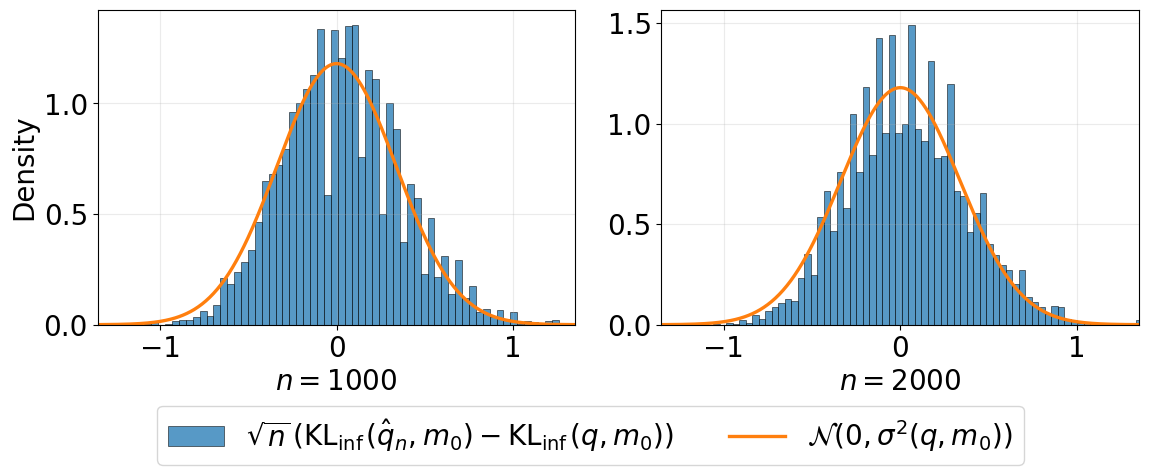

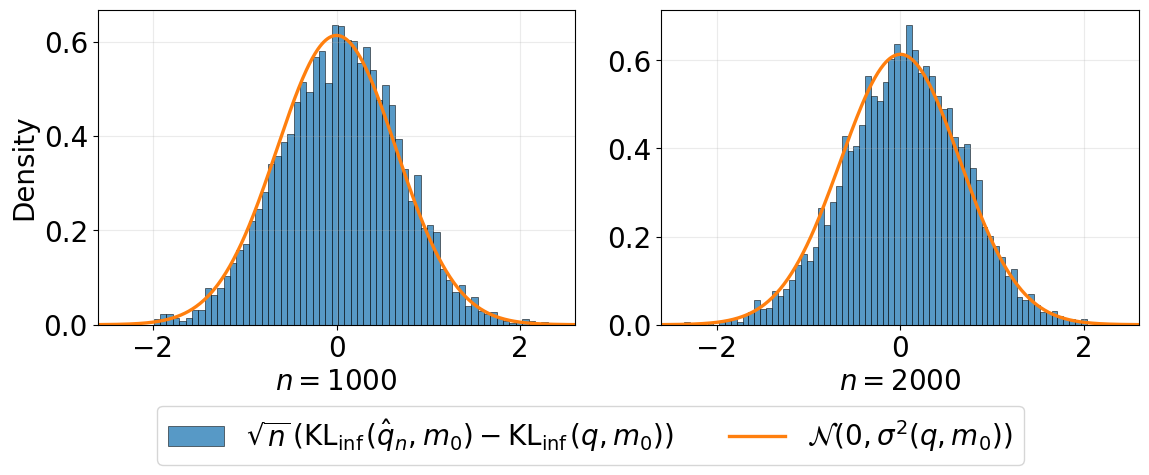

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import fsolve, root_scalar
from scipy.stats import norm


# ============================================================
# A) Code-1-style KL_inf empirical: case split via Xi + Psi root
# ============================================================
def compute_kl_inf_empirical_code1_style(
    X: np.ndarray,
    m0: float,
    clip_upper: float = 0.9999,
    boundary_factor: float = 0.9999,
    eps: float = 1e-12,
) -> tuple[float, float, float]:
    """
    Returns (L_hat, lambda_hat, Xi) using Code-1 logic:
      - Xi = mean((1-m0)/(1-X_clipped))
      - if Xi < 1 -> boundary lambda_hat ~ lambda_max
      - else -> solve Psi(lambda)=0 (interior) via fsolve (with bracket fallback)

    L_hat = mean log(1 - lambda_hat*(X-m0)).
    """
    X = np.asarray(X, dtype=float)
    lambda_max = 1.0 / (1.0 - m0)
    upper = lambda_max * (1.0 - eps)

    # --- Xi check (Code 1 style) ---
    Xi = float(np.mean((1.0 - m0) / (1.0 - np.clip(X, 0.0, clip_upper))))

    # --- Case 1: boundary ---
    if Xi < 1.0:
        lam_hat = lambda_max * boundary_factor
        lam_hat = min(max(lam_hat, 0.0), upper)
    else:
        # --- Case 2 (and the ">=1" bucket): solve Psi(lambda)=0 ---
        def psi(lam: float) -> float:
            denom = 1.0 - lam * (X - m0)
            if np.any(denom <= 0):
                return 1e10
            return float(-np.mean((X - m0) / denom))

        # 1) try bracketed root if sign change exists (more stable)
        lam_hat = None
        try:
            psi0 = psi(0.0)
            psihi = psi(upper)
            if np.isfinite(psi0) and np.isfinite(psihi) and (psi0 * psihi < 0):
                sol = root_scalar(psi, bracket=(0.0, upper), method="brentq")
                if sol.converged:
                    lam_hat = float(sol.root)
        except Exception:
            lam_hat = None

        # 2) fallback: Code-1-like fsolve
        if lam_hat is None:
            try:
                guess = min(0.5 * lambda_max, upper * 0.5)
                lam_hat = float(fsolve(lambda t: psi(float(t)), x0=guess, maxfev=2000)[0])
            except Exception:
                lam_hat = lambda_max * boundary_factor

        # project to admissible interval (Code 1 style)
        if (lam_hat <= 0.0) or (lam_hat >= upper) or (not np.isfinite(lam_hat)):
            lam_hat = lambda_max * boundary_factor
            lam_hat = min(max(lam_hat, 0.0), upper)

    # compute L_hat
    arg = 1.0 - lam_hat * (X - m0)
    if np.any(arg <= 0):
        # should not happen if lam_hat in [0, upper), but keep safe
        return float("-inf"), lam_hat, Xi

    L_hat = float(np.mean(np.log(arg)))
    return L_hat, lam_hat, Xi


# ============================================================
# B) Population MC quantities (Code-2 setup, but Code-1 KL_inf)
# ============================================================
def compute_population_quantities_code1_style(q_dist, m0: float, n_mc: int, seed: int = 123) -> dict:
    """
    Monte Carlo approximation using n_mc samples:
      L        = KL_inf(q, m0)
      lambda*  = argmax (estimated)
      sigma^2  = Var_q( log(1 - lambda*(X-m0)) )

    Uses Code-1-style (Xi+Psi) computation on the MC sample.
    """
    rng = np.random.default_rng(seed)
    X = q_dist.rvs(size=n_mc, random_state=rng)

    L, lam_star, Xi = compute_kl_inf_empirical_code1_style(X, m0)

    ell_vals = np.log(1.0 - lam_star * (X - m0))
    sigma2 = float(np.var(ell_vals, ddof=0))

    return {
        "L": float(L),
        "lambda_star": float(lam_star),
        "Xi": float(Xi),
        "sigma2": sigma2,
        "sigma": float(np.sqrt(sigma2)),
    }


# ============================================================
# C) Simulate W_n = sqrt(n)(L_n - L)
# ============================================================
def simulate_Wn_code1_style(q_dist, m0: float, n: int, L_true: float, n_paths: int, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    W = np.empty(n_paths, dtype=float)

    for r in range(n_paths):
        X = q_dist.rvs(size=n, random_state=rng)
        L_hat, _, _ = compute_kl_inf_empirical_code1_style(X, m0)
        W[r] = np.sqrt(n) * (L_hat - L_true)

    return W


# ============================================================
# D) Plot: one distribution per figure, 3 panels, overlay N(0,sigma^2)
# ============================================================
def plot_histograms_one_dist_minimal(dist_result: dict, ns: list[int]):
    sigma = dist_result["sigma"]
    W_by_n = dist_result["W"]

    fig, axes = plt.subplots(1, len(ns), figsize=(5.6 * len(ns), 4.2))
    if len(ns) == 1:
        axes = [axes]

    x_lo, x_hi = -4.0 * sigma, 4.0 * sigma
    x_grid = np.linspace(x_lo, x_hi, 500)

    hist_handle = None
    curve_handle = None

    for j, n in enumerate(ns):
        ax = axes[j]
        W = W_by_n[n]
        bin_width = 0.05
        bins = np.arange(
            np.floor(W.min() / bin_width) * bin_width,
            np.ceil(W.max()  / bin_width) * bin_width + bin_width,
            bin_width,
        )

        h = ax.hist(
            W,
            bins=70,
            #bins=bins,
            density=True,
            alpha=0.75,
            edgecolor="black",
            linewidth=0.5,
            label=r"$\sqrt{n}\,(\mathrm{KL}_{\inf}(\hat q_n,m_0)-\mathrm{KL}_{\inf}(q,m_0))$",
        )
        if hist_handle is None and len(h[2]) > 0:
            hist_handle = h[2][0]

        (line,) = ax.plot(
            x_grid,
            norm.pdf(x_grid, loc=0.0, scale=sigma),
            linewidth=2.4,
            label=r"$\mathcal{N}(0,\sigma^2(q,m_0))$",
        )
        if curve_handle is None:
            curve_handle = line

        ax.set_xlim(x_lo, x_hi)
        ax.set_xlabel(rf"$n={n}$", fontsize=20)
        if j == 0:
            ax.set_ylabel("Density", fontsize=20)
        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.grid(True, alpha=0.25)

    fig.subplots_adjust(left=0.06, right=0.99, top=0.97, bottom=0.22, wspace=0.18)

    fig.legend(
        [hist_handle, curve_handle],
        [
            r"$\sqrt{n}\,(\mathrm{KL}_{\inf}(\hat q_n,m_0)-\mathrm{KL}_{\inf}(q,m_0))$",
            r"$\mathcal{N}(0,\sigma^2(q,m_0))$",
        ],
        loc="upper center",
        ncol=2,
        frameon=True,
        fontsize=20,
        bbox_to_anchor=(0.5, 0.06),
    )

    return fig


# ============================================================
# E) Run: Code-2 experiment design, Code-1 KL_inf computation
# ============================================================
if __name__ == "__main__":
    m0 = 0.75
    ns = [1000, 2000]
    n_paths = 5000
    n_mc_pop = 400_000

    distributions = {
        "Bernoulli(0.6)": stats.bernoulli(0.6),
        "Beta(3,2)": stats.beta(3, 2),
    }

    all_results = {}

    for name, dist in distributions.items():
        pop = compute_population_quantities_code1_style(dist, m0, n_mc=n_mc_pop, seed=123)

        W_by_n = {}
        for n in ns:
            W_by_n[n] = simulate_Wn_code1_style(dist, m0, n, pop["L"], n_paths=n_paths, seed=10_000 + n)

        all_results[name] = {"W": W_by_n, **pop}

        print("=" * 80)
        print(f"{name}")
        print(f"  MC L = {pop['L']:.8f}")
        print(f"  MC lambda* = {pop['lambda_star']:.8f}")
        print(f"  MC Xi = {pop['Xi']:.8f}")
        print(f"  MC sigma = {pop['sigma']:.8f}")

    # ---- Figure 1: Bernoulli ----
    fig_b = plot_histograms_one_dist_minimal(all_results["Bernoulli(0.6)"], ns)
    plt.show()
    # fig_b.savefig("bernoulli_clt_code1klinf.pdf", bbox_inches="tight")

    # ---- Figure 2: Beta ----
    fig_beta = plot_histograms_one_dist_minimal(all_results["Beta(3,2)"], ns)
    plt.show()
    # fig_beta.savefig("beta_clt_code1klinf.pdf", bbox_inches="tight")


In [ ]:
fig_b.savefig("bernoulli_clt_klinf.pdf", bbox_inches="tight")
fig_beta.savefig("beta_clt_klinf.pdf", bbox_inches="tight")